# Importazione e installazione delle librerie

In [ ]:
# Per il test e le metriche di valutazione
!pip install -q scikit-image tensorflow tensorflow_hub resampy pystoi openl3

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Per il caricamento del Dataset
import os
import glob
import random
import shutil
import subprocess

# Per la preparazione e l'analisi del Dataset
import matplotlib.pyplot as plt
import numpy as np
import wave
import librosa
import librosa.display
import seaborn as sns

# Per riprodurre l'audio su colab
from IPython.display import Audio

# Per la definizione del modello U-Net
import torch
import torch.nn as nn
import torch.nn.functional as F

# Per l'addestramento e la ricerca degli iperparametri
from torch.utils.data import random_split, Dataset, DataLoader
import itertools
import gc

# Per il test e le metriche di valutazione
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import tensorflow as tf
import tensorflow_hub as hub
import resampy
from scipy.io import wavfile
from pystoi.stoi import stoi
import openl3
import soundfile as sf
from scipy.spatial.distance import cosine

# Caricamento del Dataset
- Importazione del dataset
- Conversione delle tracce dal formato mp3 al formato wav

In [ ]:
#Importazione del Dataset FMA, versione small da 8.000 brani
!wget https://os.unil.cloud.switch.ch/fma/fma_small.zip
!unzip fma_small.zip

Streaming output truncated to the last 5000 lines.
 bunzipping: fma_small/068/068600.mp3  
 bunzipping: fma_small/068/068601.mp3  
 bunzipping: fma_small/068/068680.mp3  
 bunzipping: fma_small/068/068682.mp3  
 bunzipping: fma_small/068/068683.mp3  
 bunzipping: fma_small/068/068820.mp3  
 bunzipping: fma_small/068/068821.mp3  
 bunzipping: fma_small/068/068837.mp3  
 bunzipping: fma_small/068/068838.mp3  
 bunzipping: fma_small/068/068839.mp3  
 bunzipping: fma_small/068/068840.mp3  
 bunzipping: fma_small/068/068841.mp3  
 bunzipping: fma_small/068/068842.mp3  
 bunzipping: fma_small/068/068843.mp3  
 bunzipping: fma_small/068/068844.mp3  
 bunzipping: fma_small/068/068851.mp3  
 bunzipping: fma_small/068/068852.mp3  
 bunzipping: fma_small/068/068853.mp3  
 bunzipping: fma_small/068/068854.mp3  
 bunzipping: fma_small/068/068860.mp3  
 bunzipping: fma_small/068/068861.mp3  
 bunzipping: fma_small/068/068862.mp3  
 bunzipping: fma_small/068/068869.mp3  
 bunzipping: fma_small/068/06

In [ ]:
#Raccolta di ognuna delle 8000 tracce estratte in un'unica lista
tracks = glob.glob("fma_small/**/*.mp3", recursive=True)

#Selezione di un sottoinsieme casuale della lista di 3000 tracce, altrimenti si appesantisce troppo il colab
random.seed(16)
random.shuffle(tracks)
tracks = tracks[:3000]

#Raccolta delle tracce di tracks in una cartella sample/dataset.mp3, rinominandole tutte,
#in modo da non fare confusione con fma_small
os.makedirs("sample/dataset", exist_ok=True)
for i, track in enumerate(tracks):
  filename = f"{i:04}.mp3"
  dst = os.path.join("sample/dataset", filename)
  shutil.copy(track, dst)

In [ ]:
#Conversione delle tracce mp3 in formato .wav
mp3_files_sample = glob.glob("sample/dataset/*.mp3")
for mp3_file in mp3_files_sample:
    wav_file = mp3_file.replace("clean_mp3", "clean").replace(".mp3", ".wav")
    subprocess.run([
        "ffmpeg", "-y", "-i", mp3_file,
        "-ar", "44100", "-ac", "1", wav_file
    ])
    os.remove(mp3_file)

In [ ]:
shutil.rmtree('/content/fma_small')

# Preparazione del Dataset
- Selezione di una parte di tre secondi da ogni file audio
- Divisione dei file audio nei sottoinsiemi di train, validation e test
- Preparazione delle trasformate di Fourier degli audio di train, validation e test che devono essere passate al modello

In [ ]:
#Funzione che restituisce le caratteristiche principali di un file audio
def read_file (filename):
    obj = wave.open(f'/content/sample/dataset/{filename[-8:]}','rb')

    n_frames = obj.getnframes()
    nchannels = obj.getnchannels()
    samplewidth = obj.getsampwidth()
    framerate = obj.getframerate()
    signal_wave = obj.readframes(-1)

    obj.close()
    return filename, n_frames, nchannels, samplewidth, framerate, signal_wave

In [ ]:
read_file('content/sample/dataset/0000.wav')[:5]

('content/sample/dataset/0000.wav', 1321967, 1, 2, 44100)

In [ ]:
def rewrite_and_write(audio_features):
    filename, n_frames, nchannels, samplewidth, framerate, signal_wave = audio_features
    signal_array = np.frombuffer(signal_wave, dtype=np.int16)[-(3 * framerate):]

    if len(signal_array) < 3 * framerate:
        os.remove(filename)
        return

    #Sovrascrive l'originale con i soli 3 secondi finali
    with wave.open(filename, 'wb') as old_obj:
        old_obj.setnframes(len(signal_array))
        old_obj.setnchannels(nchannels)
        old_obj.setsampwidth(samplewidth)
        old_obj.setframerate(framerate)
        old_obj.writeframes(signal_array.tobytes())

In [ ]:
#Creazione di una cartella noise in cui verranno inseriti tutti i file audio con il rumore gaussiano
samples = glob.glob("sample/dataset/*.wav")
for sample in samples:
    rewrite_and_write(read_file(sample))

In [ ]:
#Divido il dataset in train/test/val
from sklearn.model_selection import train_test_split
all_wavs = sorted(glob.glob("sample/dataset/*.wav"))
#Suddivido in 80% train e 20%test
train, temp = train_test_split(all_wavs, test_size=0.2, random_state=16)
#Ulteriore divisione di test, in 10% test e 10 %validation
val, test = train_test_split(temp, test_size=0.5, random_state=16)

#Salvo le cartelle di train,test e val
os.makedirs("sample/splits", exist_ok=True)
with open("sample/splits/train.txt", "w") as f:
    f.writelines([f"{w}\n" for w in train])
with open("sample/splits/val.txt", "w") as f:
    f.writelines([f"{w}\n" for w in val])
with open("sample/splits/test.txt", "w") as f:
    f.writelines([f"{w}\n" for w in test])

In [ ]:
sound_file = "sample/dataset/0000.wav"
Audio(sound_file, rate=22050, autoplay=False)

In [ ]:
#Funzione che fa la trasformata di Fourier di un file audio e le aggiunge del rumore
#Le versioni pulita e rumorosa vengono salvate come tensori

def Fourier_clean_and_noisy (paths):
  X = []
  Y = []

  for filepath in paths:
      y, _ = librosa.load(filepath, sr=22050)
      Fourier_clean = librosa.stft(y, n_fft=1024, hop_length=512).astype(np.float32)
      Fourier_noisy = Fourier_clean + np.random.normal(0, 0.5, size=Fourier_clean.shape)

      if Fourier_clean.shape == Fourier_noisy.shape:
          X.append(Fourier_noisy[np.newaxis, ...])
          Y.append(Fourier_clean[np.newaxis, ...])

  return X, Y

In [ ]:
#Preparazione degli spettrogrammi per il training
with open ('/content/sample/splits/train.txt') as f:
  songs_train = f.readlines()
f.close()

paths_train = sorted([s[:-1] for s in songs_train])

X, Y = Fourier_clean_and_noisy (paths_train)
X_train = torch.tensor(np.array(X), dtype=torch.float32)
Y_train = torch.tensor(np.array(Y), dtype=torch.float32)

print(X_train.shape)  # [N, 1, H, W]

/tmp/ipython-input-13-2447930798.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  Fourier_clean = librosa.stft(y, n_fft=1024, hop_length=512).astype(np.float32)


torch.Size([2398, 1, 513, 130])


In [ ]:
#Preparazione degli spettrogrammi per il validation
with open ('/content/sample/splits/val.txt') as f:
  songs_val = f.readlines()
f.close()

paths_val = sorted([s[:-1] for s in songs_val])

X, Y = Fourier_clean_and_noisy (paths_val)
X_val = torch.tensor(np.array(X), dtype=torch.float32)
Y_val = torch.tensor(np.array(Y), dtype=torch.float32)

print(X_val.shape)  #[N, 1, H, W]

/tmp/ipython-input-13-2447930798.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  Fourier_clean = librosa.stft(y, n_fft=1024, hop_length=512).astype(np.float32)


torch.Size([300, 1, 513, 130])


In [ ]:
#Preparazione degli spettrogrammi per il test
with open ('/content/sample/splits/test.txt') as f:
  songs_test = f.readlines()
f.close()

paths_test = sorted([s[:-1] for s in songs_test])

X, Y = Fourier_clean_and_noisy (paths_test)
X_test = torch.tensor(np.array(X), dtype=torch.float32)
Y_test = torch.tensor(np.array(Y), dtype=torch.float32)

print(X_test.shape)  #[N, 1, H, W]

/tmp/ipython-input-13-2447930798.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  Fourier_clean = librosa.stft(y, n_fft=1024, hop_length=512).astype(np.float32)


torch.Size([300, 1, 513, 130])


# Analisi dei dati
- Grafico del segnale audio nel tempo
- Spettrogramma e spettrogramma logaritmico
- RMS
- Banda Spettrale
- Centroide Spettrale
- Flatness Spettrale
- MFCC
- Zero Crossing Rate
- Correlazione tra audio pulito e rovinato (e correlazione media)
- SNR stimato (e SNR medio)

In [ ]:
#Prendiamo un esempio dal dataset di training, lo riconvertiamo in audio con l'inversa della trasformata di Fourier
name = paths_train[0][-8:]
clean_prova = librosa.istft(Y_train[0].cpu().squeeze().numpy(), n_fft=1024, hop_length=512)
noisy_prova = librosa.istft(X_train[0].cpu().squeeze().numpy(), n_fft=1024, hop_length=512)

In [ ]:
#Riproduzione del file audio pulito
sound_file = clean_prova
Audio(sound_file, rate=22050, autoplay=False)

In [ ]:
#Riproduzione del file audio corrispondente rumoroso
sound_file = noisy_prova
Audio(sound_file, rate=22050, autoplay=False)

### Segnale audio nel tempo

In [ ]:
#Funzione che crea il grafico del segnale audio nel tempo

def audio_graph (name):
    audio_features = read_file(f'/content/sample/dataset/{name}')
    filename, n_frames, nchannels, samplewidth, framerate, signal_wave = audio_features

    t_audio = n_frames / framerate
    signal_array = np.frombuffer(signal_wave, dtype=np.int16)
    times = np.linspace (0, t_audio, num = n_frames)

    plt.figure(figsize = (15,5))
    plt.plot(times, signal_array)
    plt.title(f"Segnale audio di {name}")
    plt.ylabel("Signal wave")
    plt.xlabel("Time (s)")
    plt.xlim(0, t_audio)

    plt.show()

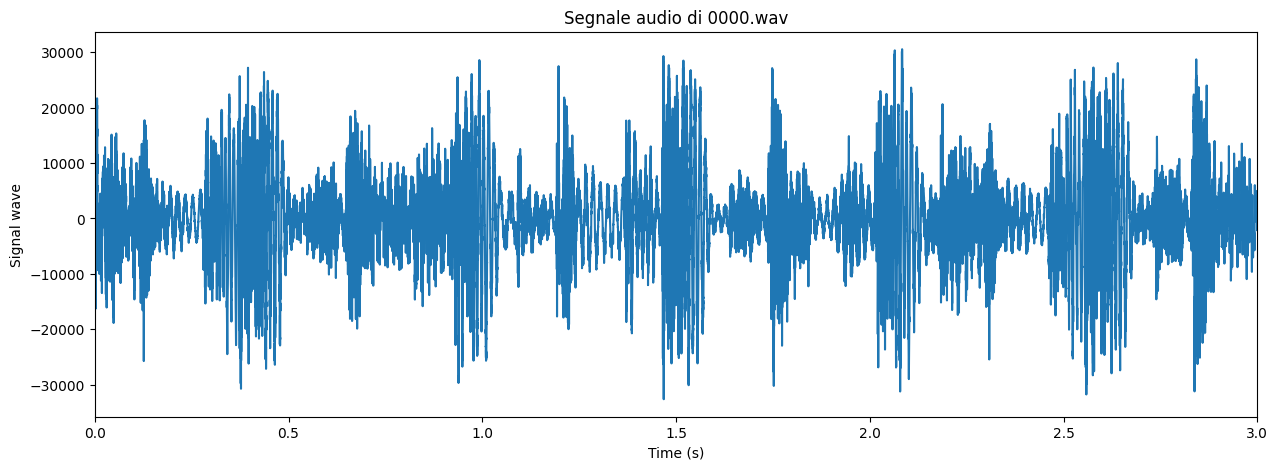

In [ ]:
audio_graph (name)

### Spettrogramma
Lo spettrogramma mostra la distribuzione delle frequenze nel tempo. È come una “fotografia” delle frequenze presenti. Ci da una mappa colorata dove l’asse X è il tempo, Y è la frequenza, e i colori mostrano l’intensità (giallo = forte, blu = debole).

In [ ]:
def spectrogram_graph (name, y, kind):

    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=512))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    spec_noisy = (S_db + 80) / 80  #Normalizza tra [0,1]

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spec_noisy.squeeze(), sr=22050, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'spettrogramma {kind}')
    plt.tight_layout()
    plt.show()

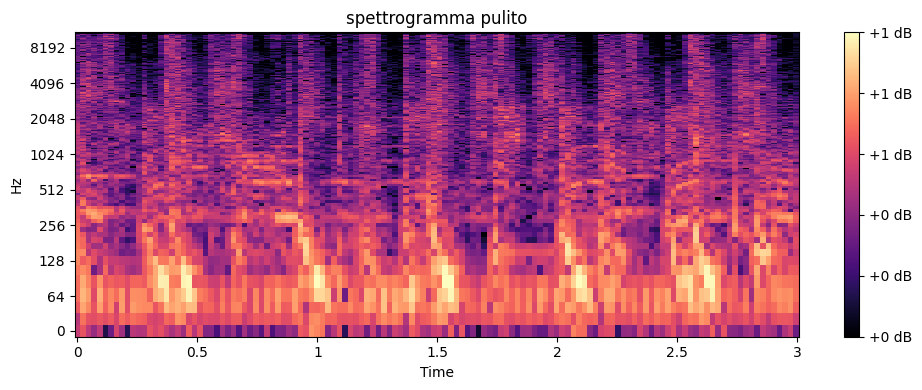

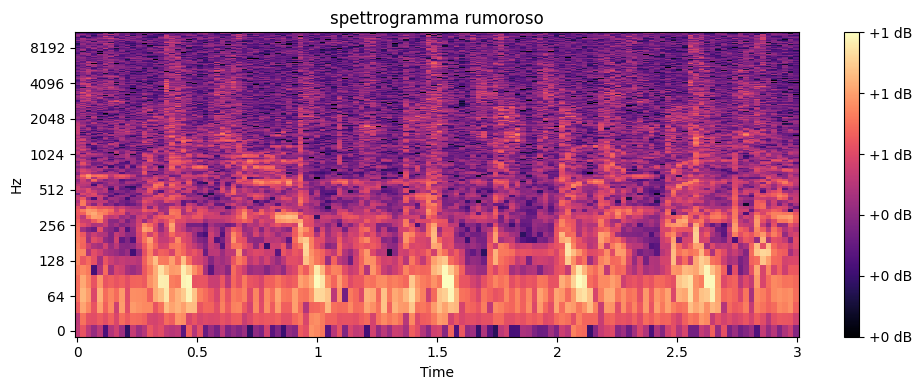

In [ ]:
spectrogram_graph (name, clean_prova, 'pulito')
spectrogram_graph (name, noisy_prova, 'rumoroso')

###Energia RMS (Root Mean Square)
L’energia RMS misura quanto è forte il segnale in media. Serve a vedere quanto “potente” è il suono. Ci da una curva che segue i picchi dell’audio: più è alto, più energia c’è.

In [ ]:
def rms_graph (name, y1, y2, y3=None):
  rms_clean = librosa.feature.rms(y=y1.squeeze())[0]
  rms_noisy = librosa.feature.rms(y=y2.squeeze())[0]
  if type(y3) == np.ndarray:
    rms_predicted = librosa.feature.rms(y=y3.squeeze())[0]
  times_clean = librosa.frames_to_time(range(len(rms_clean)), sr=22050)

  plt.figure(figsize=(10, 4))
  plt.plot(times_clean, rms_clean, label='Pulito', color='green')
  plt.plot(times_clean, rms_noisy, label='Rovinato', color='red', alpha=0.5)
  if type(y3) == np.ndarray:
    plt.plot(times_clean, rms_predicted, label='Denoised', color='blue', alpha=0.5)
  plt.title(f'Energia RMS nel Tempo di {name}')
  plt.xlabel('Tempo (s)')
  plt.ylabel('Energia RMS')
  plt.legend()
  plt.tight_layout()
  plt.show()

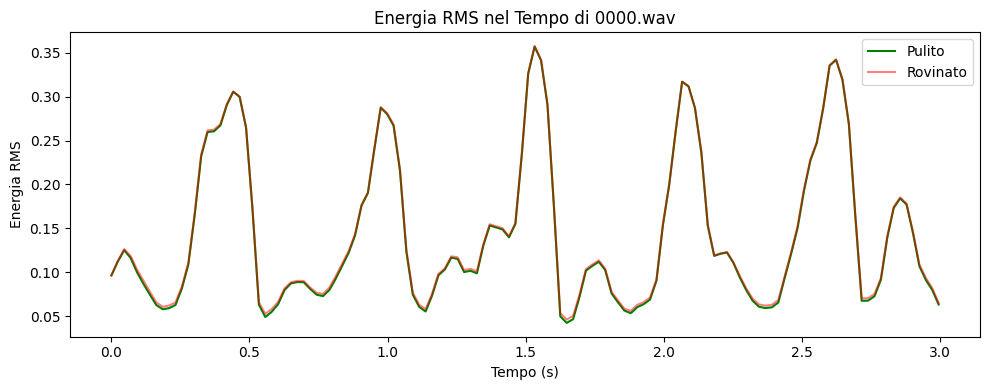

In [ ]:
rms_graph (name, clean_prova, noisy_prova)

### Banda Spettrale (Spectral Bandwidth)
La banda spettrale misura quanto si estendono le frequenze in un determinato istante. Se il suono è ricco di frequenze alte e basse insieme, la banda è più ampia.
Ci da una curva nel tempo che varia: più è alta, più lo spettro è “largo”.

In [ ]:
def spec_bw_graph (name, y1, y2, y3=None):
  spec_bw_clean = librosa.feature.spectral_bandwidth(y=y1.squeeze(), sr=22050)[0]
  spec_bw_noisy = librosa.feature.spectral_bandwidth(y=y2.squeeze(), sr=22050)[0]
  if type(y3) == np.ndarray:
    spec_bw_predicted = librosa.feature.spectral_bandwidth(y=y3.squeeze(), sr=22050)[0]
  times = librosa.times_like(spec_bw_clean, sr=22050)

  plt.figure(figsize=(10, 4))
  plt.plot(times, spec_bw_clean, label='Pulito', color='green')
  plt.plot(times, spec_bw_noisy, label='Rovinato', color='red', alpha=0.5)
  if type(y3) == np.ndarray:
    plt.plot(times, spec_bw_predicted, label='Denoised', color='blue', alpha=0.5)
  plt.title(f'Banda Spettrale di {name}')
  plt.xlabel('Tempo (s)')
  plt.ylabel('Hz')
  plt.legend()
  plt.tight_layout()
  plt.show()

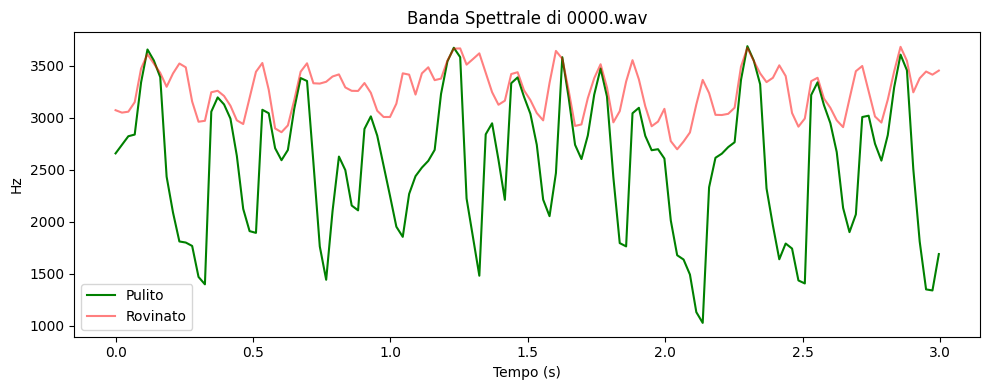

In [ ]:
spec_bw_graph (name, clean_prova, noisy_prova)

### Centroide Spettrale (Spectral Centroid)

Il centroide è il "baricentro" dello spettro: se è alto, ci sono più frequenze alte nel suono.

Ci da una curva che mostra la tendenza verso suoni più gravi o acuti nel tempo.


In [ ]:
def centroid_graph (name, y1, y2, y3=None):
  centroid_clean = librosa.feature.spectral_centroid(y=y1.squeeze(), sr=22050)[0]
  centroid_noisy = librosa.feature.spectral_centroid(y=y2.squeeze(), sr=22050)[0]
  if type(y3) == np.ndarray:
    centroid_predicted = librosa.feature.spectral_centroid(y=y3.squeeze(), sr=22050)[0]
  times = librosa.times_like(centroid_clean, sr=22050)

  plt.figure(figsize=(10, 4))
  plt.plot(times, centroid_clean, label='Pulito', color='green')
  plt.plot(times, centroid_noisy, label='Rovinato', color='red', alpha=0.5)
  if type(y3) == np.ndarray:
    plt.plot(times, centroid_predicted, label='Denoised', color='blue', alpha=0.5)
  plt.title(f'Centroide Spettrale di {name}')
  plt.xlabel('Tempo (s)')
  plt.ylabel('Hz')
  plt.legend()
  plt.tight_layout()
  plt.show()

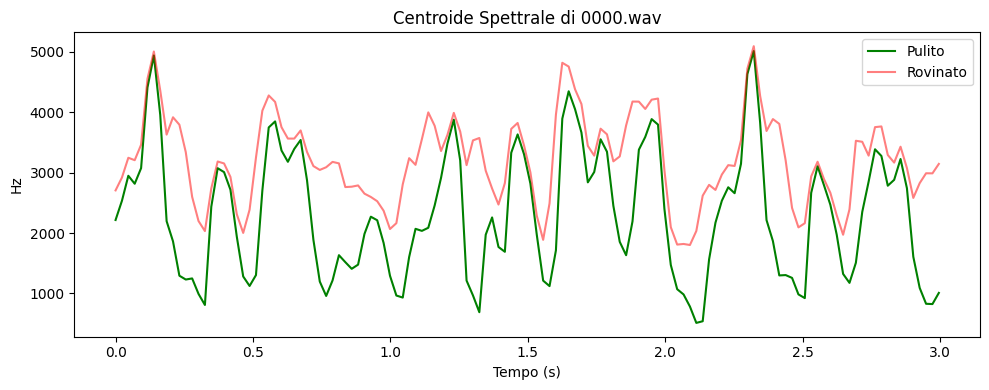

In [ ]:
centroid_graph(name, clean_prova, noisy_prova)

### Flatness Spettrale (Spectral Flatness)

La flatness indica quanto il suono è simile al rumore bianco: un suono musicale ha flatness bassa, un rumore ha flatness alta.

Ci da una curva nel tempo che oscilla tra 0 (armonico) e 1 (casuale).


In [ ]:
def flatness_graph (name, y1, y2, y3=None):
  flatness_clean = librosa.feature.spectral_flatness(y=y1.squeeze())[0]
  flatness_noisy = librosa.feature.spectral_flatness(y=y2.squeeze())[0]
  if type(y3) == np.ndarray:
    flatness_predicted = librosa.feature.spectral_flatness(y=y3.squeeze())[0]
  times = librosa.times_like(flatness_clean, sr=22050)

  plt.figure(figsize=(10, 4))
  plt.plot(times, flatness_clean, label='Pulito', color='green')
  plt.plot(times, flatness_noisy, label='Rovinato', color='red', alpha=0.5)
  if type(y3) == np.ndarray:
    plt.plot(times, flatness_predicted, label='Denoised', color='blue', alpha=0.5)
  plt.title(f'Flatness Spettrale di {name}')
  plt.xlabel('Tempo (s)')
  plt.ylabel('Flatness')
  plt.legend()
  plt.tight_layout()
  plt.show()

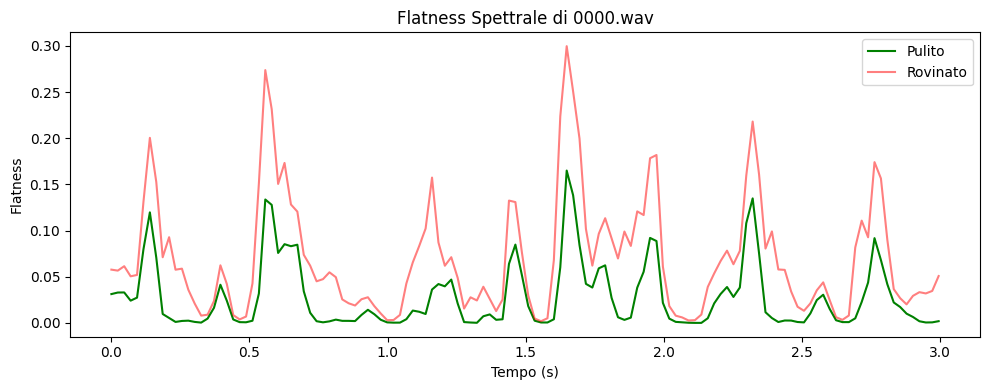

In [ ]:
flatness_graph (name, clean_prova, noisy_prova )

###MFCC (Mel Frequency Cepstral Coefficients)

Gli MFCC rappresentano il contenuto timbrico del suono. Sono molto usati per confrontare suoni (es. nella classificazione).

Ci da una “mappa termica” con 13-20 linee orizzontali nel tempo: ogni linea è un coefficiente.


In [ ]:
def mfcc_graph (name, y, kind):
  mfcc = librosa.feature.mfcc(y=y.squeeze(), sr=22050, n_mfcc=13)

  if (type(y) == np.ndarray):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, sr=22050, x_axis='time')
    plt.colorbar()
    plt.title(f'MFCC di {name} {kind}')
    plt.tight_layout()
    plt.show()

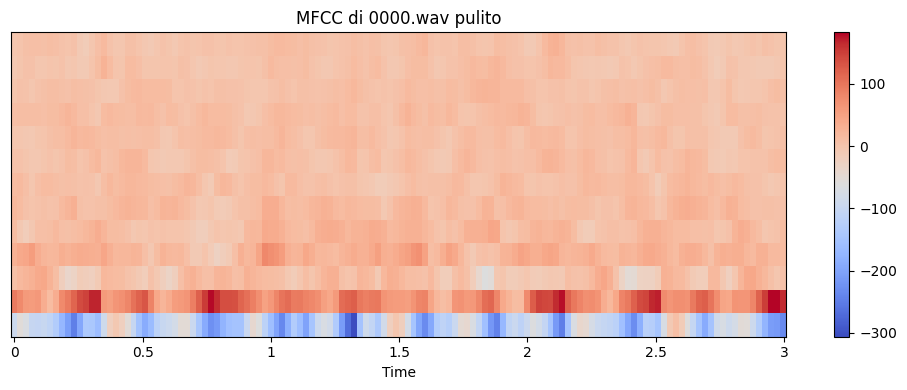

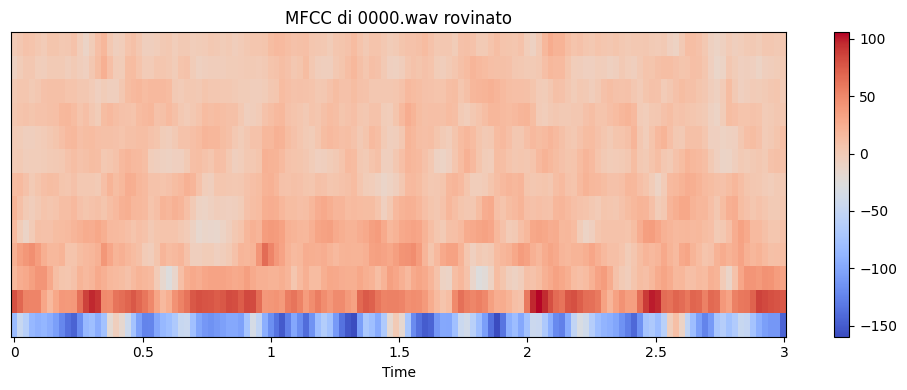

In [ ]:
mfcc_graph (name, clean_prova, 'pulito')
mfcc_graph (name, noisy_prova, 'rovinato')

### ZCR (Zero Crossing Rate)

Conta quante volte il segnale attraversa lo zero. I suoni più fruscianti o acuti hanno ZCR più alta.

Ci dà una curva con picchi alti nei momenti di rumore.


In [ ]:
def zcr_graph (name, y1, y2, y3=None):
  zcr_clean = librosa.feature.zero_crossing_rate(y=y1.squeeze())[0]
  zcr_noisy = librosa.feature.zero_crossing_rate(y=y2.squeeze())[0]
  if type(y3) == np.ndarray:
      zcr_predicted = librosa.feature.zero_crossing_rate(y=y3.squeeze())[0]
  times = librosa.times_like(zcr_clean, sr=22050)

  plt.figure(figsize=(10, 4))
  plt.plot(times, zcr_clean, label='Pulito', color='green')
  plt.plot(times, zcr_noisy, label='Rovinato', color='red', alpha=0.5)
  if type(y3) == np.ndarray:
      plt.plot(times, zcr_predicted, label='Denoised', color='blue', alpha=0.5)
  plt.title(f'Zero Crossing Rate di {name}')
  plt.xlabel('Tempo (s)')
  plt.ylabel('Rate')
  plt.legend()
  plt.tight_layout()
  plt.show()

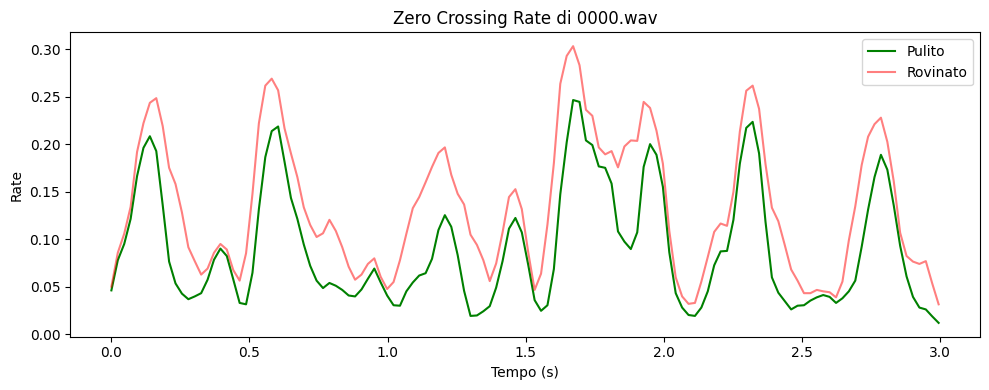

In [ ]:
zcr_graph (name, clean_prova, noisy_prova)

###Correlazione tra audio pulito e rovinato

Serve per vedere quanto i due segnali sono simili. Più la correlazione è vicina a 1, più sono simili.


In [ ]:
def correlation_fun (name, y1, y2, kind):
  correlation = np.corrcoef(y1, y2)[0, 1]
  print(f'Correlazione tra i due audio {name}, {kind}: {correlation:.2f}')

In [ ]:
correlation_fun (name, clean_prova, noisy_prova, 'pulito e rumoroso')

Correlazione tra i due audio 0000.wav, pulito e rumoroso: 0.99


In [ ]:
#Correlazione media nel dataset di train
def avg_correlation (X, Y):
  correlation_list = []

  for Fourier_clean, Fourier_noisy in zip(Y, X):
      clean = librosa.istft(Fourier_clean.cpu().squeeze().numpy(), n_fft=1024, hop_length=512)
      noisy = librosa.istft(Fourier_noisy.cpu().squeeze().numpy(), n_fft=1024, hop_length=512)

      correlation = np.corrcoef(clean, noisy)[0, 1]
      # Negli audio completamente silenziosi correlation = nan
      if np.isnan(correlation) == False:
          correlation_list.append(correlation)

  print(f'Correlazione media tra un audio pulito e il suo corrispondente sporco: {np.mean(correlation_list):.2f}')

In [ ]:
avg_correlation(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlazione media tra un audio pulito e il suo corrispondente sporco: 0.96


In [ ]:
avg_correlation(X_val, Y_val)

Correlazione media tra un audio pulito e il suo corrispondente sporco: 0.96


In [ ]:
avg_correlation(X_test, Y_test)

Correlazione media tra un audio pulito e il suo corrispondente sporco: 0.97


### SNR stimato (Signal-to-Noise Ratio):

Misura quanto il segnale utile è più forte del rumore. Più è alto, più l’audio è "pulito".


In [ ]:
def snr_fun (name, y1, y2, kind):
  signal_power = np.mean(y1 ** 2)
  noise_power = np.mean((y1 - y2) ** 2)
  snr = 10 * np.log10(signal_power / noise_power)
  print(f'SNR stimato per i due audio {name}, {kind}: {snr:.2f} dB')

In [ ]:
snr_fun(name, clean_prova, noisy_prova, 'pulto e rumoroso')

SNR stimato per i due audio 0000.wav, pulto e rumoroso: 19.06 dB


In [ ]:
#Snr medio nel dataset di train
def avg_snr (X, Y):
  snr_list = []

  for Fourier_clean, Fourier_noisy in zip(Y, X):
        clean = librosa.istft(Fourier_clean.cpu().squeeze().numpy(), n_fft=1024, hop_length=512)
        noisy = librosa.istft(Fourier_noisy.cpu().squeeze().numpy(), n_fft=1024, hop_length=512)

        signal_power = np.mean(clean ** 2)
        noise_power = np.mean((clean - noisy) ** 2)
        snr = 10 * np.log10(signal_power / noise_power)

        #Negli audio completamente silenziosi per cui snr = -inf
        if (snr != float('-inf')) and np.isnan(snr) == False:
           snr_list.append(snr)

  print(f'SNR medio stimato: {np.mean(snr_list)}')

In [ ]:
avg_snr (X_train, Y_train)

/tmp/ipython-input-44-3248214224.py:11: RuntimeWarning: divide by zero encountered in log10
  snr = 10 * np.log10(signal_power / noise_power)


SNR medio stimato: 14.948471069335938


In [ ]:
avg_snr (X_val, Y_val)

SNR medio stimato: 15.102181434631348


In [ ]:
avg_snr (X_test, Y_test)

SNR medio stimato: 15.81926441192627


# Definizione del modello U-Net
- Definizione di una classe dataset che restituisce un audio pulito e il corrispondente rumoroso
- Spectral Loss
- Definizione della U-Net, del blocco convoluzionale e dello Squeeze and Excitation Block

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#Dataset compatibile con X, Y
class AudioDenoisingDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [ ]:
#Spectral Loss
class SpectralLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        pred = torch.clamp(pred, min=1e-6, max=1.0)
        target = torch.clamp(target, min=1e-6, max=1.0)
        linear = self.mse(pred, target)
        log = self.mse(torch.log(pred), torch.log(target))
        return (self.alpha * linear + (1 - self.alpha) * log)

#Squeeze-and-Excite Block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

#Convolutional Block
def conv_block(in_ch, out_ch, dropout_rate=0.1):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.LeakyReLU(inplace=True),
        nn.Dropout2d(dropout_rate),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.LeakyReLU(inplace=True),
        SEBlock(out_ch)
    )

#U-Net con Residual Learning
class ImprovedUNet2(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        #Final layer: input + skip connection = 64 + in_channels
        self.final = nn.Sequential(
            nn.Conv2d(64 + in_channels, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(32, out_channels, kernel_size=1)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))


        d3 = self.up3(b)
        d3 = self._pad_if_needed(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self._pad_if_needed(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self._pad_if_needed(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        d1 = torch.cat([d1, x], dim=1)
        out = self.final(d1)

        return x - out  #residual

    def _pad_if_needed(self, x, ref):
        diffY = ref.size(2) - x.size(2)
        diffX = ref.size(3) - x.size(3)
        if diffY != 0 or diffX != 0:
            x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                          diffY // 2, diffY - diffY // 2])
        return x


# Addestramento e ricerca degli iperparametri
- Addestramento della U-Net
- Grid search con grafico della loss per il modello migliore

In [ ]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
#Training + validazione
def train_and_validate(model, train_loader, val_loader, epochs, device, loss_fn, optimizer):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for noisy, clean in train_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            optimizer.zero_grad()
            output = model(noisy)
            loss = loss_fn(output, clean)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss = validate(model, val_loader, device, loss_fn)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1}/{epochs} - Train: {avg_train_loss:.4f} - Val: {avg_val_loss:.4f}")
        torch.save(model.state_dict(), "last_checkpoint.pth")

    return train_losses, val_losses

#Validazione
def validate(model, val_loader, device, loss_fn):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for noisy, clean in val_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            output = model(noisy)
            loss = loss_fn(output, clean)
            total_loss += loss.item()
    return total_loss / len(val_loader)



In [ ]:
#Grid search ottimizzata
def grid_search_model(X_train, Y_train, X_val, Y_val, model_class, param_grid, device):

    train_set = AudioDenoisingDataset(X_train, Y_train)
    val_set = AudioDenoisingDataset(X_val, Y_val)

    best_score = float('inf')
    best_params = None
    best_losses = None

    combinations = list(itertools.product(
        param_grid['batch_size'],
        param_grid['epochs'],
        param_grid['learning_rate'],
        param_grid['alpha']
        ))

    for batch_size, epochs, lr, alpha in combinations:
        print(f"\n Testing batch_size={batch_size}, epochs={epochs}, lr={lr}, alpha={alpha}, (Adam)")

        train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

        model = None
        optimizer = None

        try:
            model = model_class().to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            loss_fn = SpectralLoss(alpha=alpha)

            train_losses, val_losses = train_and_validate(
                model, train_loader, val_loader, epochs, device, loss_fn, optimizer
            )

            final_val_loss = val_losses[-1]
            if final_val_loss < best_score:
                best_score = final_val_loss
                best_params = {
                    'batch_size': batch_size,
                    'epochs': epochs,
                    'learning_rate': lr,
                    'alpha' : alpha
                }
                best_losses = (train_losses, val_losses)

        except RuntimeError as e:
            print(f" Skipped combo due to error: {e}")

        finally:
            del model
            del optimizer
            torch.cuda.empty_cache()
            gc.collect()

    #Grafico finale solo per la combinazione migliore
    if best_losses:
        train_losses, val_losses = best_losses
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f"Best model - {best_params}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    print(f"\n Best parameters: {best_params} with validation loss: {best_score:.4f}")
    return best_params
param_grid = {
    'batch_size': [4, 8],
    'epochs': [5],
    'learning_rate': [1e-4, 1e-5],
    'alpha': [1]
}

In [ ]:
#Ricerca degli iperparametri con la grid search
'''
model = ImprovedUNet2().to(device)
best_params = grid_search_model(X_train, Y_train, X_val, Y_val, ImprovedUNet2, param_grid, device)
torch.save(model.state_dict(), "best_model.pth")
'''

'\nmodel = ImprovedUNet2().to(device)\nbest_params = grid_search_model(X_train, Y_train, X_val, Y_val, ImprovedUNet2, param_grid, device)\ntorch.save(model.state_dict(), "best_model.pth")\n'

In [ ]:
#Addestramento del modello con i parametri migliori trovati nella grid search in 20 epoche
model = ImprovedUNet2().to(device)

train_set = AudioDenoisingDataset(X_train, Y_train)
val_set = AudioDenoisingDataset(X_val, Y_val)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

loss_fn = SpectralLoss(alpha=1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 20

train_losses, val_losses = train_and_validate(
    model, train_loader, val_loader, epochs=epochs, device=device, loss_fn=loss_fn, optimizer=optimizer
)

Epoch 1/20 - Train: 0.0286 - Val: 0.0176
Epoch 2/20 - Train: 0.0171 - Val: 0.0161
Epoch 3/20 - Train: 0.0163 - Val: 0.0154
Epoch 4/20 - Train: 0.0158 - Val: 0.0150
Epoch 5/20 - Train: 0.0155 - Val: 0.0148
Epoch 6/20 - Train: 0.0152 - Val: 0.0147
Epoch 7/20 - Train: 0.0150 - Val: 0.0147
Epoch 8/20 - Train: 0.0149 - Val: 0.0145
Epoch 9/20 - Train: 0.0147 - Val: 0.0143
Epoch 10/20 - Train: 0.0146 - Val: 0.0143
Epoch 11/20 - Train: 0.0145 - Val: 0.0141
Epoch 12/20 - Train: 0.0144 - Val: 0.0141
Epoch 13/20 - Train: 0.0143 - Val: 0.0141
Epoch 14/20 - Train: 0.0143 - Val: 0.0140
Epoch 15/20 - Train: 0.0142 - Val: 0.0139
Epoch 16/20 - Train: 0.0141 - Val: 0.0139
Epoch 17/20 - Train: 0.0140 - Val: 0.0138
Epoch 18/20 - Train: 0.0139 - Val: 0.0138
Epoch 19/20 - Train: 0.0139 - Val: 0.0137
Epoch 20/20 - Train: 0.0139 - Val: 0.0138


# Test e metriche di valutazione

 ## Definizione metriche di valutazione

###FAD (Fréchet Audio Distance):

Confronta la distribuzione degli embedding tra ground truth e audio restaurato.
Valuta quanto il dominio delle feature dell'audio generato si discosta da quello dell'audio reale.
Più basso, meglio è.

In [ ]:
#Caricamento modello VGGish (embedding audio)
modelVGG = hub.load('https://tfhub.dev/google/vggish/1')

def fad(output_desiderato, output_modello, sr=16000):
    #Estrazione embedding
    emb1 = modelVGG(output_desiderato)
    emb2 = modelVGG(output_modello)

    #Calcolo FAD
    mu1 = np.mean(emb1, axis=1)
    mu2 = np.mean(emb2, axis=1)
    fad = np.linalg.norm(mu1 - mu2)
    print(f"Approx. FAD:", fad)

###STOI (Short-Time Objective Intelligibility):

Più usata per la voce, ma utile anche in musica per valutare la chiarezza dopo denoising. Ritorna un punteggio tra 0 e 1. Più alto, meglio è.


In [ ]:
# Entrambe le tracce devono avere la stessa lunghezza e sample rate
def stoi_score (output_desiderato, output_modello):
  min_len = min(len(output_desiderato), len(output_modello))
  desiderato_trim = output_desiderato[:min_len]
  modello_trim = output_modello[:min_len]

  score = stoi(desiderato_trim, modello_trim, 16000, extended=False)
  print("STOI score:", score)

### OpenL3 Embeddings Similarity:

Genera una rappresentazione (embedding) del contenuto audio, calcola similarità tra versioni degradate e restaurate.


In [ ]:
# Funzione per estrarre l'embedding medio
def get_openl3_embedding (audio, sr=48000):

    # Mono
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)

    emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)

    # Ritorna la media degli embedding temporali
    return np.mean(emb, axis=0)

# Calcola embedding medio per ciascun file
def cosine_similarity (audio_desiderato, audio_output):
    emb1 = get_openl3_embedding(audio_desiderato)
    emb2 = get_openl3_embedding(audio_desiderato)

    # Similarità coseno (1 - distanza)
    similarity = 1 - cosine(emb1, emb2)
    print("OpenL3 Cosine Similarity:", similarity)

### Altre metriche
Corrispondono ai grafici definiti nella sezione di Analisi dei dati

In [ ]:
# Funzione che chiama le funzioni definite nella sezione di Analisi dei dati
def compare_audio (name, y1, y2, y3=None,
                   spectrogram=False, mfcc=False,
                   rms=False, spec_bw=False, centroid=False, flatness=False, zcr=False,
                   correlation=False, snr=False,
                   audio=False):

  if spectrogram:
    spectrogram_graph (name, y1, 'pulito')
    spectrogram_graph (name, y2, 'rumoroso')
    spectrogram_graph (name, y3, 'ricostruito')

  if mfcc:
    mfcc_graph (name, y1, 'pulito')
    mfcc_graph (name, y2, 'rumoroso')
    mfcc_graph (name, y3, 'ricostruito')

  if rms:
    rms_graph (name, y1, y2, y3)

  if spec_bw:
    spec_bw_graph (name, y1, y2, y3)

  if centroid:
    centroid_graph (name, y1, y2, y3)

  if flatness:
    flatness_graph (name, y1, y2, y3)

  if zcr:
    zcr_graph (name, y1, y2, y3)

  if correlation:
    correlation_fun (name, y1, y2, 'pulito e rumoroso')
    if type(y3) == np.ndarray:
      correlation_fun (name, y1, y3, 'pulito e denoised')
      correlation_fun (name, y2, y3, 'rumoroso e denoised')

  if snr:
    snr_fun (name, y1, y2, 'pulito e rumoroso')
    if type(y3) == np.ndarray:
      snr_fun (name, y1, y3, 'pulito e denoised')
      snr_fun (name, y2, y3, 'rumoroso e denoised')

  if audio==True:
    clean_audio = Audio(y1, rate=22050, autoplay = False)
    noisy_audio = Audio(y2, rate=22050, autoplay = False)

    if type(y3) == np.ndarray:
      predicted_audio = Audio(y3, rate=22050, autoplay = False)
      return  clean_audio, noisy_audio, predicted_audio

    return clean_audio, noisy_audio


## Test

In [ ]:
def test_model_only(X_test, Y_test, model_class, model_path="best_model.pth"):

    # Split del dataset in test set

    test_set = AudioDenoisingDataset(X_test, Y_test)
    test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

    # Caricamento modello

    model = model_class().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Loss functions
    spectral_loss_fn = SpectralLoss(alpha=0.5)
    mse_fn = nn.MSELoss()

    spectral_total = 0.0
    mse_total = 0.0
    psnr_list = []
    ssim_list = []
    predictions = []
    targets = []
    inputs = []

    with torch.no_grad():
        for noisy, clean in test_loader:
            noisy, clean = noisy.to(device), clean.to(device)

            output = model(noisy)  # denoised output (residual learning)

            loss_spectral = spectral_loss_fn(output, clean)
            loss_mse = mse_fn(output, clean)

            spectral_total += loss_spectral.item()
            mse_total += loss_mse.item()

            pred_np = output.cpu().squeeze().numpy()
            target_np = clean.cpu().squeeze().numpy()
            input_np = noisy.cpu().squeeze().numpy()

            predictions.append(pred_np)
            targets.append(target_np)
            inputs.append(input_np)

            psnr_list.append(psnr(target_np, pred_np, data_range=1.0))
            ssim_list.append(ssim(target_np, pred_np, data_range=1.0))


    print(f"\n[Test Results]")
    print(f" SpectralLoss = {spectral_total / len(test_loader):.6f}")
    print(f" MSE          = {mse_total / len(test_loader):.6f}")
    print(f" PSNR         = {np.mean(psnr_list):.2f} dB")
    print(f" SSIM         = {np.mean(ssim_list):.3f}")

    # Visualizzazione primo risultato

    filename = paths_test[21][-8:]
    audiosignal_clean = librosa.istft(targets[21].squeeze(), n_fft=1024, hop_length=512)
    audiosignal_noisy = librosa.istft(inputs[21].squeeze(), n_fft=1024, hop_length=512)
    audiosignal_predicted = librosa.istft(predictions[21].squeeze(), n_fft=1024, hop_length=512)


    target_clean, input_noisy, predicted_denoised = compare_audio (filename, audiosignal_clean, audiosignal_noisy, audiosignal_predicted,
                                                                   spectrogram=True, mfcc=True,
                                                                   rms=True, spec_bw=True, centroid=True, flatness=True, zcr=True,
                                                                   correlation=True, snr=True, audio=True)

    fad (audiosignal_clean, audiosignal_predicted)
    stoi_score (audiosignal_clean, audiosignal_predicted)
    cosine_similarity (audiosignal_clean, audiosignal_predicted)

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return target_clean, input_noisy, predicted_denoised



[Test Results]
 SpectralLoss = 17.451897
 MSE          = 0.818977
 PSNR         = 2.25 dB
 SSIM         = 0.005


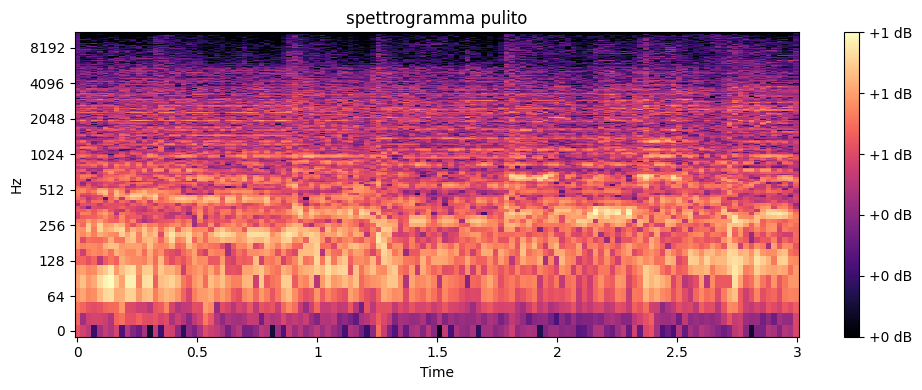

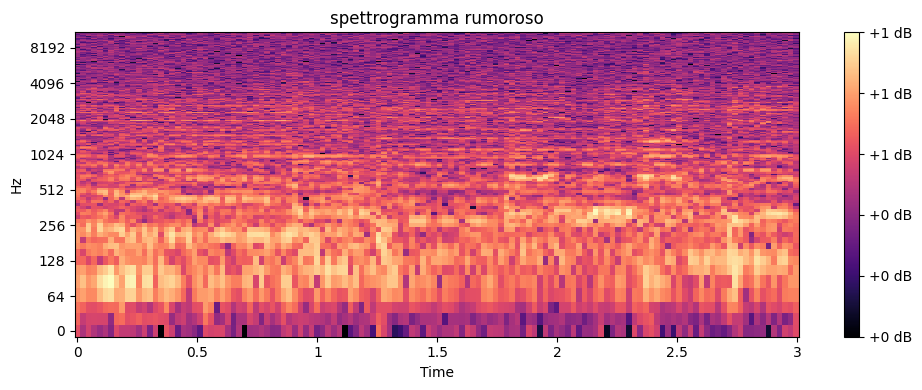

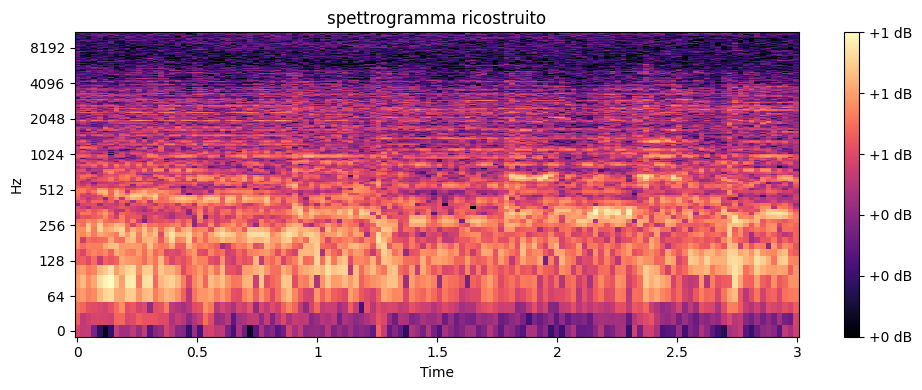

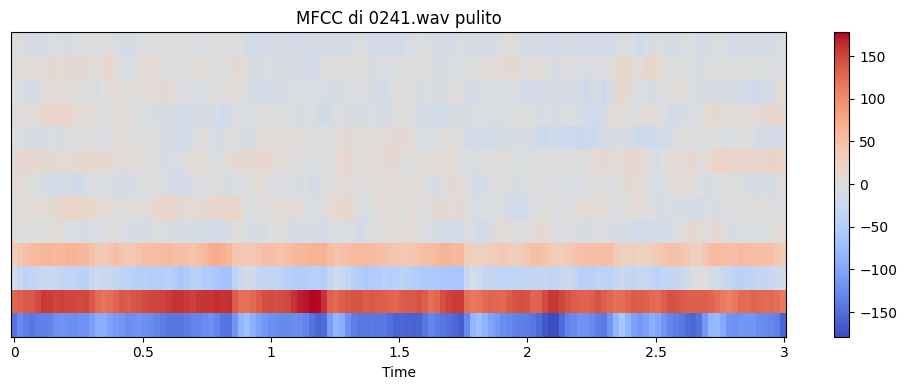

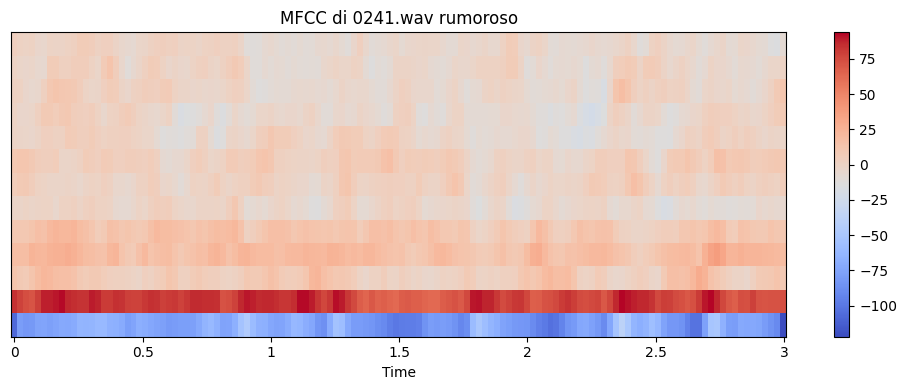

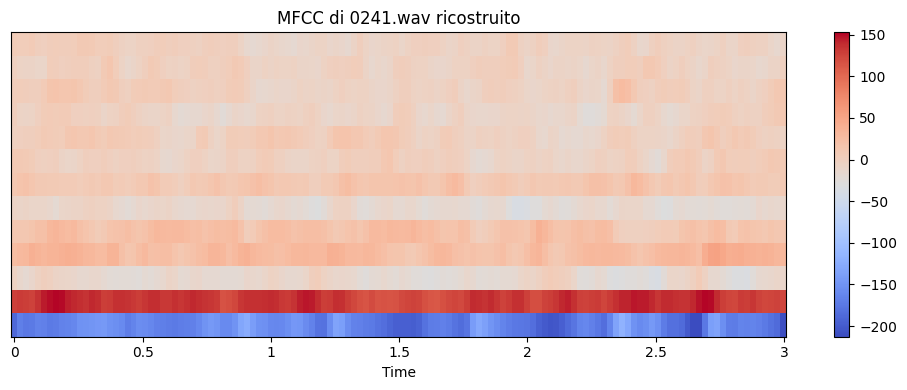

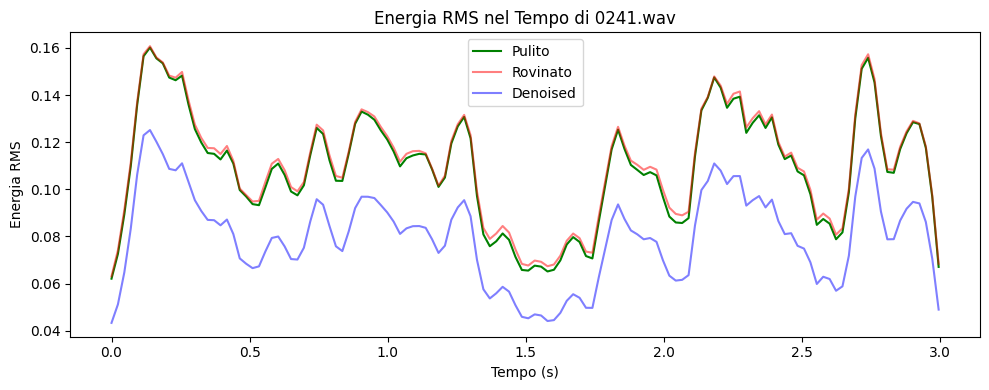

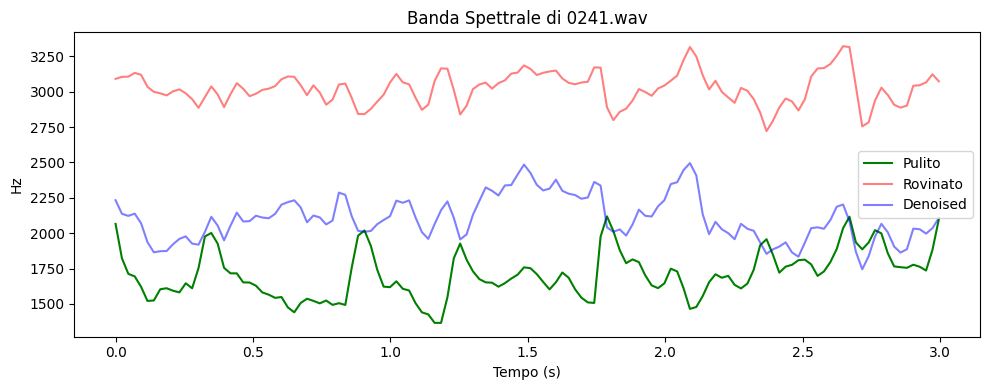

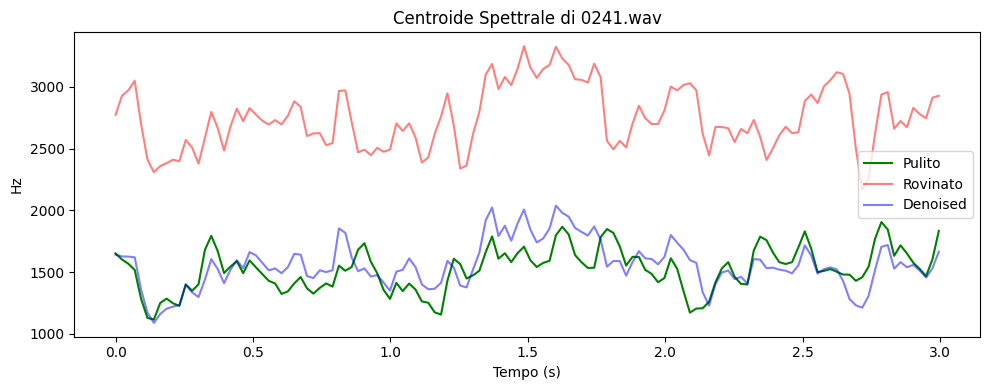

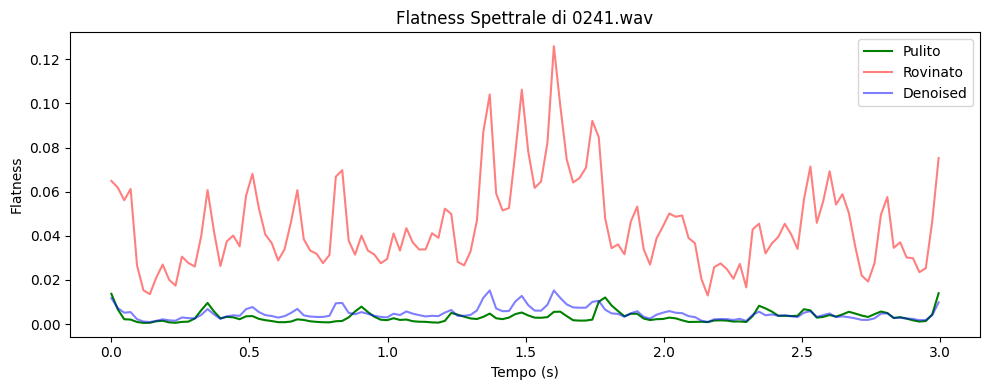

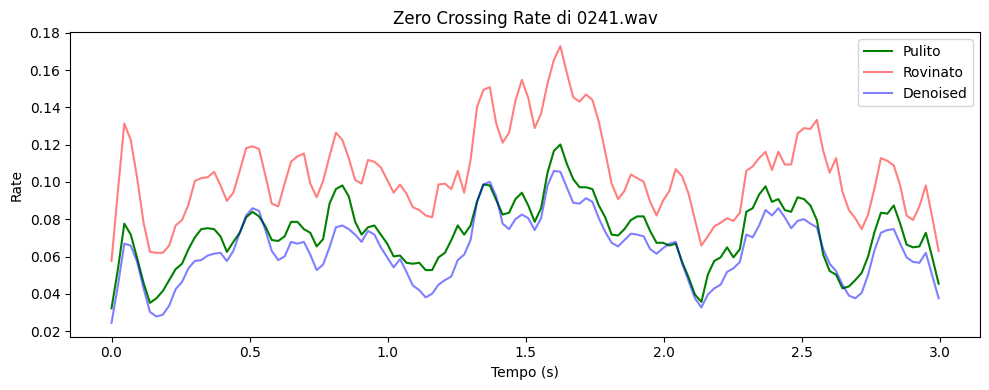

Correlazione tra i due audio 0241.wav, pulito e rumoroso: 0.99
Correlazione tra i due audio 0241.wav, pulito e denoised: 0.99
Correlazione tra i due audio 0241.wav, rumoroso e denoised: 0.99
SNR stimato per i due audio 0241.wav, pulito e rumoroso: 15.62 dB
SNR stimato per i due audio 0241.wav, pulito e denoised: 10.91 dB
SNR stimato per i due audio 0241.wav, rumoroso e denoised: 10.45 dB
Approx. FAD: 0.06933428
STOI score: 0.9495864997340345
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
OpenL3 Cosine Similarity: 1.0


In [ ]:
target_clean, input_noisy, predicted_denoised = test_model_only(X_test, Y_test, ImprovedUNet2, 'last_checkpoint.pth')

In [ ]:
# Ground truth
target_clean

In [ ]:
# Input
input_noisy

In [ ]:
# Output
predicted_denoised

# Modello Demucs

### Librerie per il modello Demucs

In [ ]:
!pip install -q torchaudio demucs soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 7.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 755.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [ ]:
import soundfile as sf

### Test del modello Demucs su un file audio

PSNR: 30.79 dB
SSIM (spectrogram): 0.7489
File 'denoised.wav' salvato con successo.


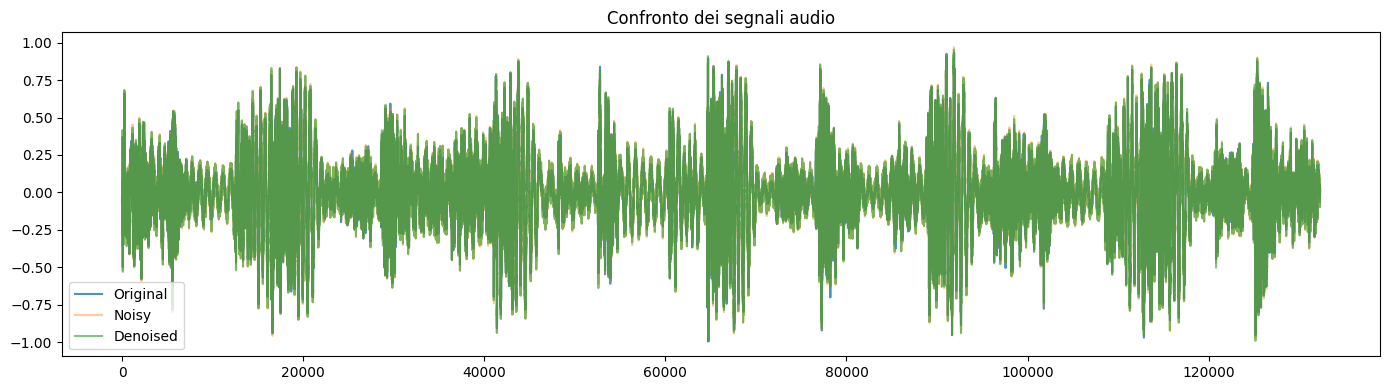

In [ ]:
#Carica audio originale e aggiungi rumore
audio_path = "/content/sample/dataset/0000.wav"
y, sr = librosa.load(audio_path, sr=44100, mono=True)
noise = np.random.normal(0, 0.03, y.shape)
y_noisy = np.clip(y + noise, -1.0, 1.0)
sf.write("noisy_track.wav", y_noisy, sr)

#Esegui Demucs via CLI
subprocess.run(["python3", "-m", "demucs", "noisy_track.wav"])

#Trova cartella output di Demucs
output_root = "separated/htdemucs"
subdirs = os.listdir(output_root)
assert len(subdirs) > 0, "Demucs non ha prodotto output."
stems_dir = os.path.join(output_root, subdirs[0])  # es: noisy_track

#Somma gli stem se esistono
denoised = np.zeros_like(y)
stem_names = ["drums.wav", "bass.wav", "other.wav", "vocals.wav"]
for stem in stem_names:
    path = os.path.join(stems_dir, stem)
    if os.path.exists(path):
        s, _ = librosa.load(path, sr=sr, mono=True)
        denoised[:len(s)] += s

#Funzioni metriche
def compute_psnr(clean, denoised):
    mse = np.mean((clean - denoised) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

def compute_ssim_spectrogram(y1, y2, sr):
    S1 = librosa.feature.melspectrogram(y=y1, sr=sr, n_mels=128)
    S2 = librosa.feature.melspectrogram(y=y2, sr=sr, n_mels=128)
    S1_db = librosa.power_to_db(S1, ref=np.max)
    S2_db = librosa.power_to_db(S2, ref=np.max)
    score, _ = ssim(S1_db, S2_db, data_range=S1_db.max() - S1_db.min(), full=True)
    return score

#Calcola metriche
psnr = compute_psnr(y, denoised)
ssim_score = compute_ssim_spectrogram(y, denoised, sr)
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM (spectrogram): {ssim_score:.4f}")

#Salva risultato
sf.write("denoised.wav", denoised, sr)
print("File 'denoised.wav' salvato con successo.")

#Grafico comparativo
plt.figure(figsize=(14, 4))
plt.plot(y, label="Original", alpha=0.8)
plt.plot(y_noisy, label="Noisy", alpha=0.4)
plt.plot(denoised, label="Denoised", alpha=0.6)
plt.title("Confronto dei segnali audio")
plt.legend()
plt.tight_layout()
plt.show()

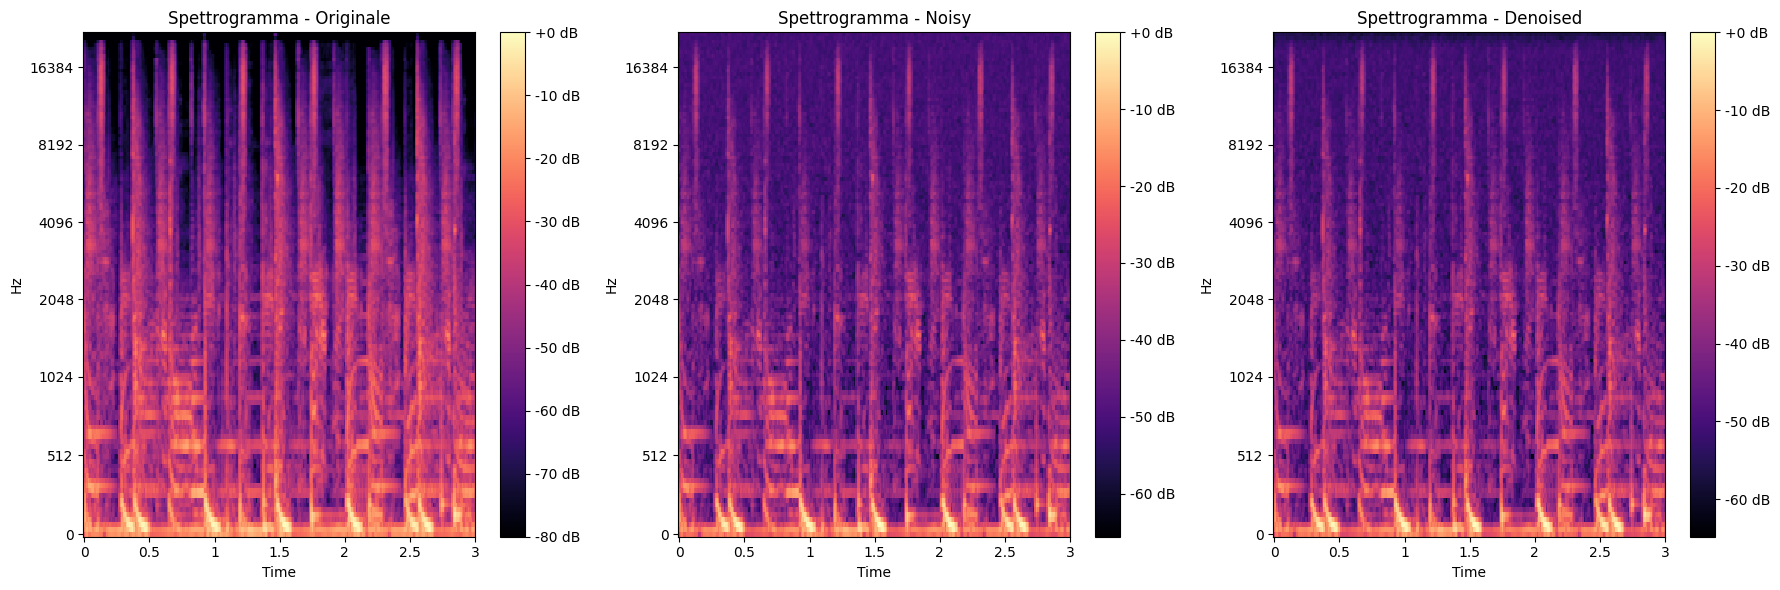

In [ ]:
#Visualizza spettrogrammi: Original, Noisy, Denoised
plt.figure(figsize=(18, 6))

#Originale
plt.subplot(1, 3, 1)
S_orig = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_orig_db = librosa.power_to_db(S_orig, ref=np.max)
librosa.display.specshow(S_orig_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Spettrogramma - Originale')

#Noisy
plt.subplot(1, 3, 2)
S_noisy = librosa.feature.melspectrogram(y=y_noisy, sr=sr, n_mels=128)
S_noisy_db = librosa.power_to_db(S_noisy, ref=np.max)
librosa.display.specshow(S_noisy_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Spettrogramma - Noisy')

#Denoised
plt.subplot(1, 3, 3)
S_denoised = librosa.feature.melspectrogram(y=denoised, sr=sr, n_mels=128)
S_denoised_db = librosa.power_to_db(S_denoised, ref=np.max)
librosa.display.specshow(S_denoised_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Spettrogramma - Denoised')

plt.tight_layout()
plt.show()
